In [201]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Task 1**

In [202]:
df = pd.read_csv("/content/G1.csv")
df

,Response_ID,Timestamp,Age,Gender,Occupation_Status,Country_Region,Monthly_Income_Range,Shop_Most_Where,Online_Shopping_Frequency,Preferred_Platform,...,Return_Frequency,Avg_Monthly_Spend_NonEssentials,Preferred_Payment_Method,Uses_BNPL_Installments,Online_Shopping_Satisfaction_Score,Trust_In_Online_Reviews_Score,Regret_After_Purchase_Frequency,Reason_Prefer_Online,Reason_Prefer_InStore,Best_Shopping_Mode
0,1,01/08/2026 12:30:25,20,Male,NaN,Philippines,"Under $1,000",Equal mix,Often,Physical stores,...,Never,Under $50,Digital wallet,"Yes, occasionally",6.0,7.0,2.0,More variety,No delivery wait,Online
1,2,21/06/2026 13:52:02,24,Male,Employed part-time,Brazil,"Under $1,000",In-store only,Often,Local e-commerce,...,Often,Under $50,Digital wallet,"No, never",5.0,8.0,3.0,NaN,Try product before buying,Offline
2,3,15/08/2026 04:24:18,22,Female,Student,India,"Under $1,000",Equal mix,Always,Local e-commerce,...,Sometimes,$150-300,Credit Card,"No, never",7.0,6.0,2.0,Better prices,Trust,Online
3,4,23/06/2026 21:24:21,20,Male,Student,NaN,"Under $1,000",In-store only,Occasionally,Brand websites,...,Never,Under $50,Debit Card,"No, never",8.0,7.0,3.0,Better prices,Try product before buying,Equal / both
4,5,20/08/2026 16:24:47,41,Male,Employed full-time,United States,"$1,000-3,000",Equal mix,Occasionally,NaN,...,Sometimes,$50-150,Debit Card,"No, never",6.0,8.0,2.0,Convenience,Trust,Equal / both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,18/07/2026 23:18:07,42,Female,Employed full-time,India,"$1,000-3,000",Online only,Often,Global marketplace (Amazon etc.),...,Never,Under $50,Digital wallet,"Yes, regularly",4.0,5.0,2.0,More variety,Try product before buying,Online
496,497,28/06/2026 15:20:50,22,Prefer not to say,NaN,Colombia,"Under $1,000",Online only,Occasionally,Global marketplace (Amazon etc.),...,Often,Under $50,Digital wallet,"No, never",9.0,5.0,2.0,More variety,Try product before buying,Equal / both
497,498,23/06/2026 05:27:31,26,Male,Student,Brazil,NaN,Equal mix,Often,Brand websites,...,Never,$150-300,Digital wallet,"No, never",8.0,5.0,1.0,Better prices,Trust,Offline
498,499,17/07/2026 08:05:20,37,Female,Employed full-time,United Kingdom,"$6,000+",In-store only,Occasionally,Global marketplace (Amazon etc.),...,Never,$50-150,Digital wallet,"No, never",8.0,10.0,2.0,More variety,Trust,Offline


In [203]:
df.shape

(500, 30)

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Response_ID                         500 non-null    int64  
 1   Timestamp                           500 non-null    object 
 2   Age                                 478 non-null    object 
 3   Gender                              484 non-null    object 
 4   Occupation_Status                   479 non-null    object 
 5   Country_Region                      480 non-null    object 
 6   Monthly_Income_Range                479 non-null    object 
 7   Shop_Most_Where                     484 non-null    object 
 8   Online_Shopping_Frequency           481 non-null    object 
 9   Preferred_Platform                  486 non-null    object 
 10  Primary_Device                      492 non-null    object 
 11  Top_Spending_Category               476 non-n

In [205]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['Response_ID', 'Review_Influence_Score', 'Social_Ads_Influence_Score', 'Price_Comparison_Frequency', 'Discount_Importance_Score', 'Likely_To_Buy_After_Ad_Score', 'Impulse_Purchase_Frequency', 'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency']
Categorical Features: ['Timestamp', 'Age', 'Gender', 'Occupation_Status', 'Country_Region', 'Monthly_Income_Range', 'Shop_Most_Where', 'Online_Shopping_Frequency', 'Preferred_Platform', 'Primary_Device', 'Top_Spending_Category', 'Follows_Brands_On_Social', 'Makes_Shopping_List', 'Return_Frequency', 'Avg_Monthly_Spend_NonEssentials', 'Preferred_Payment_Method', 'Uses_BNPL_Installments', 'Reason_Prefer_Online', 'Reason_Prefer_InStore', 'Best_Shopping_Mode']


In [206]:
df.duplicated().sum()  #check for duplcates

np.int64(0)

In [207]:
df.isnull().sum() #check for missing values


,0
Response_ID,0
Timestamp,0
Age,22
Gender,16
Occupation_Status,21
Country_Region,20
Monthly_Income_Range,21
Shop_Most_Where,16
Online_Shopping_Frequency,19
Preferred_Platform,14


In [208]:
df.isnull().mean()*100


,0
Response_ID,0.0
Timestamp,0.0
Age,4.4
Gender,3.2
Occupation_Status,4.2
Country_Region,4.0
Monthly_Income_Range,4.2
Shop_Most_Where,3.2
Online_Shopping_Frequency,3.8
Preferred_Platform,2.8


In [209]:
df['Best_Shopping_Mode'].value_counts()

,count
Best_Shopping_Mode,
Online,218
Offline,118
Equal / both,113


Best_Shopping_Mode
Online          218
Offline         118
Equal / both    113
Name: count, dtype: int64
Best_Shopping_Mode
Online          48.552339
Offline         26.280624
Equal / both    25.167038
Name: proportion, dtype: float64


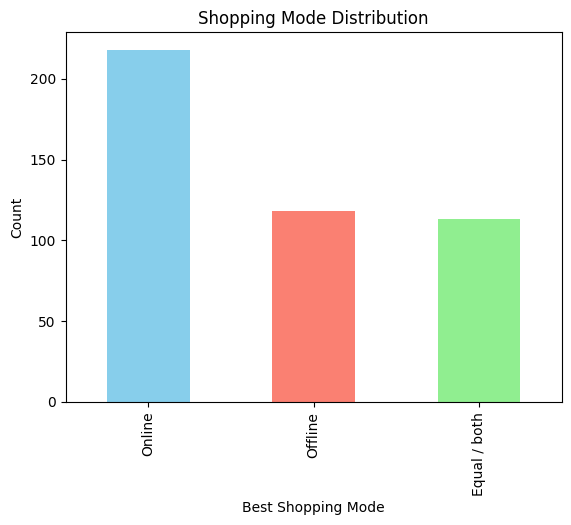

In [210]:
target = df['Best_Shopping_Mode']
print(target.value_counts())
print(target.value_counts(normalize=True) * 100)

target.value_counts().plot(kind='bar', color=['skyblue','salmon','lightgreen'])
plt.title("Shopping Mode Distribution")
plt.xlabel("Best Shopping Mode")
plt.ylabel("Count")
plt.show()

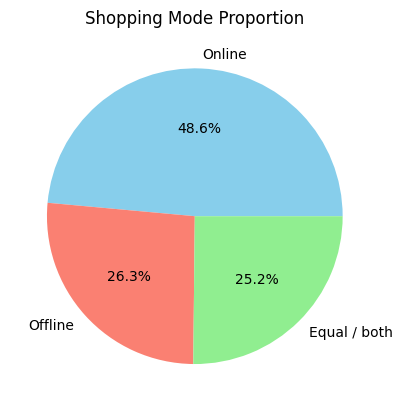

In [211]:
target.value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue','salmon','lightgreen'])
plt.title("Shopping Mode Proportion")
plt.ylabel("")
plt.show()

Analytical Questions


1.   No, dataset is imbalanced.
2.   Online shopping Category is dominate half of the survey
3.   Online shopping is leading



**Task 2  **

In [212]:
import seaborn as sns
import matplotlib.pyplot as plt

Numerical Features: ['Response_ID','Age', 'Review_Influence_Score', 'Social_Ads_Influence_Score', 'Price_Comparison_Frequency', 'Discount_Importance_Score', 'Likely_To_Buy_After_Ad_Score', 'Impulse_Purchase_Frequency', 'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency']

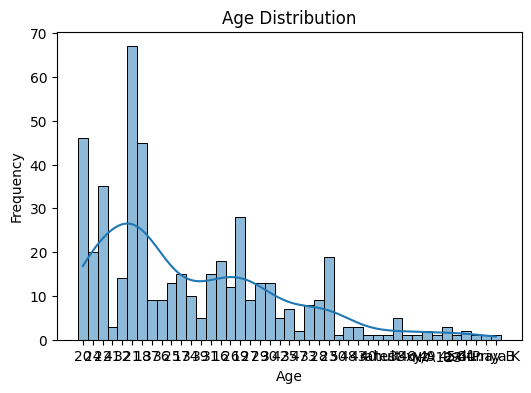

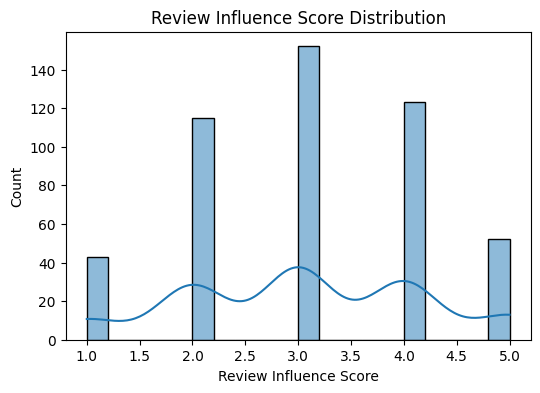

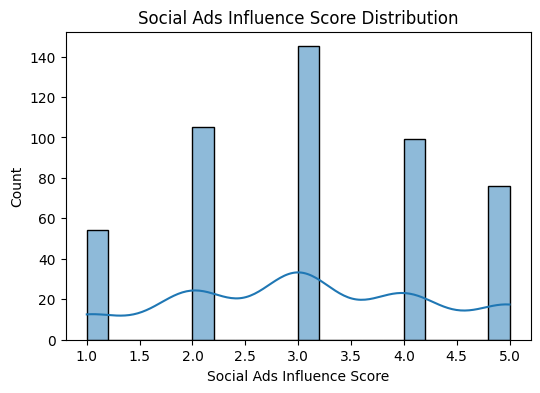

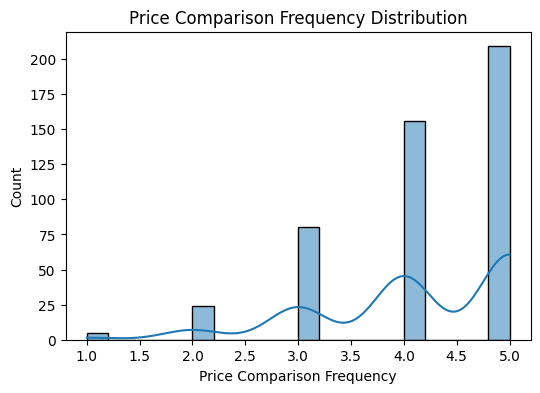

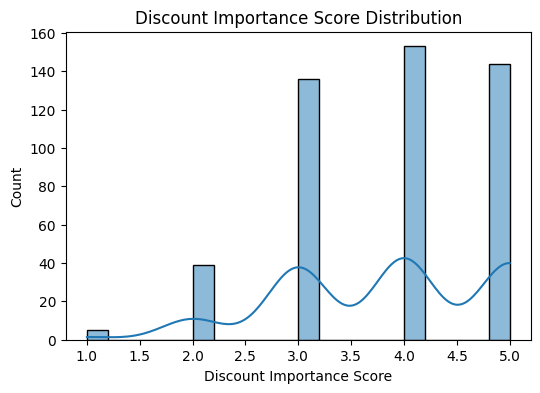

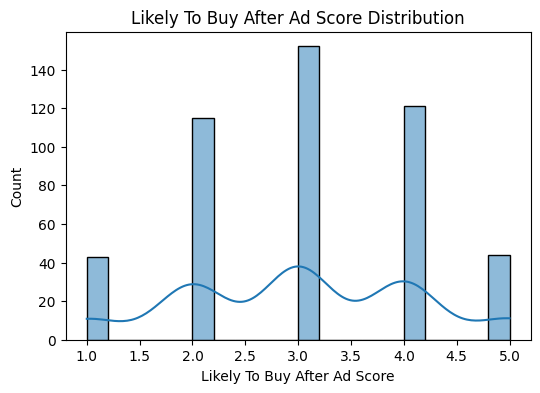

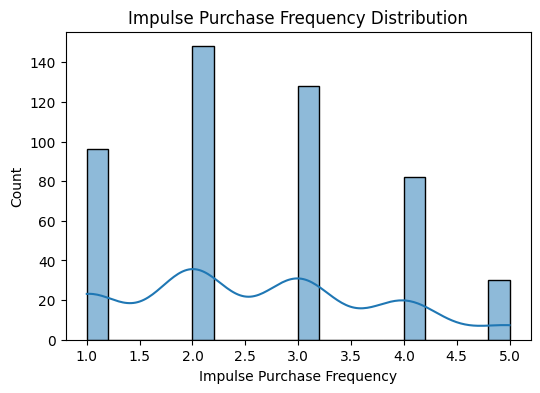

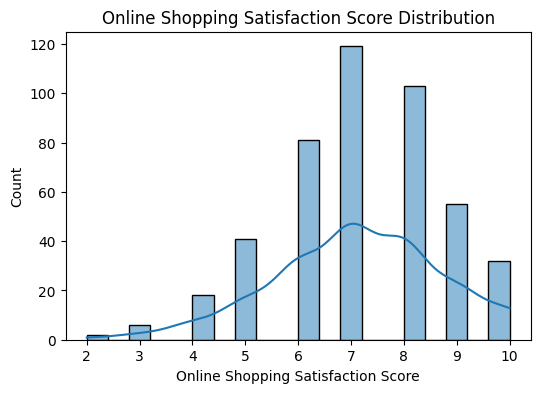

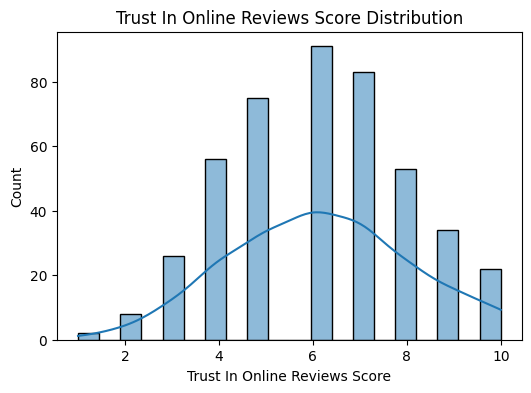

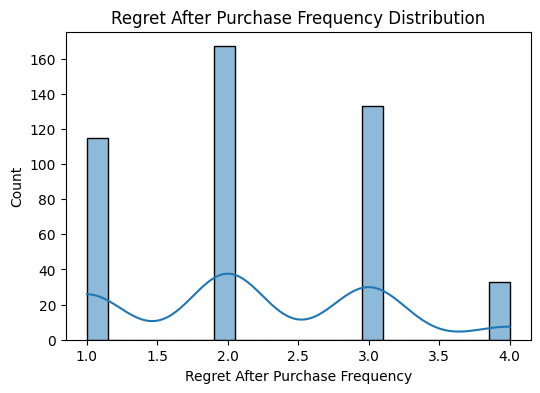

In [213]:
#histogram for Age
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Review_Influence_Score
plt.figure(figsize=(6,4))
sns.histplot(df["Review_Influence_Score"], bins=20, kde=True)
plt.title("Review Influence Score Distribution")
plt.xlabel("Review Influence Score")
plt.show()

#Social_Ads_Influence_Score
plt.figure(figsize=(6,4))
sns.histplot(df["Social_Ads_Influence_Score"], bins=20, kde=True)
plt.title("Social Ads Influence Score Distribution")
plt.xlabel("Social Ads Influence Score")
plt.show()

#Price_Comparison_Frequency
plt.figure(figsize=(6,4))
sns.histplot(df["Price_Comparison_Frequency"], bins=20, kde=True)
plt.title("Price Comparison Frequency Distribution")
plt.xlabel("Price Comparison Frequency")
plt.show()

#Discount_Importance_Score
plt.figure(figsize=(6,4))
sns.histplot(df["Discount_Importance_Score"], bins=20, kde=True)
plt.title("Discount Importance Score Distribution")
plt.xlabel("Discount Importance Score")
plt.show()

#Likely_To_Buy_After_Ad_Score
plt.figure(figsize=(6,4))
sns.histplot(df["Likely_To_Buy_After_Ad_Score"], bins=20, kde=True)
plt.title("Likely To Buy After Ad Score Distribution")
plt.xlabel("Likely To Buy After Ad Score")
plt.show()

#Impulse_Purchase_Frequency
plt.figure(figsize=(6,4))
sns.histplot(df["Impulse_Purchase_Frequency"], bins=20, kde=True)
plt.title("Impulse Purchase Frequency Distribution")
plt.xlabel("Impulse Purchase Frequency")
plt.show()

#Online_Shopping_Satisfaction_Score
plt.figure(figsize=(6,4))
sns.histplot(df["Online_Shopping_Satisfaction_Score"], bins=20, kde=True)
plt.title("Online Shopping Satisfaction Score Distribution")
plt.xlabel("Online Shopping Satisfaction Score")
plt.show()

#Trust_In_Online_Reviews_Score
plt.figure(figsize=(6,4))
sns.histplot(df["Trust_In_Online_Reviews_Score"], bins=20, kde=True)
plt.title("Trust In Online Reviews Score Distribution")
plt.xlabel("Trust In Online Reviews Score")
plt.show()

#Regret_After_Purchase_Frequency
plt.figure(figsize=(6,4))
sns.histplot(df["Regret_After_Purchase_Frequency"], bins=20, kde=True)
plt.title("Regret After Purchase Frequency Distribution")
plt.xlabel("Regret After Purchase Frequency")
plt.show()





In [214]:
# Convert Age to numeric, non-numeric becomes NaN
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Check how many missing values
print(df['Age'].isna().sum())

# Fill missing ages with median (Age is skewed)
df['Age'] = df['Age'].fillna(df['Age'].median())


30


In [215]:
#numerical features with median
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

#categorical features with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [216]:
df.isnull().sum()

,0
Response_ID,0
Timestamp,0
Age,0
Gender,0
Occupation_Status,0
Country_Region,0
Monthly_Income_Range,0
Shop_Most_Where,0
Online_Shopping_Frequency,0
Preferred_Platform,0


In [217]:
num_cols : ['Response_ID', 'Review_Influence_Score', 'Social_Ads_Influence_Score', 'Price_Comparison_Frequency', 'Discount_Importance_Score', 'Likely_To_Buy_After_Ad_Score', 'Impulse_Purchase_Frequency', 'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency']

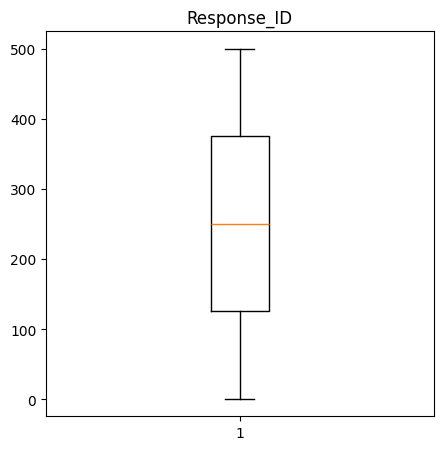

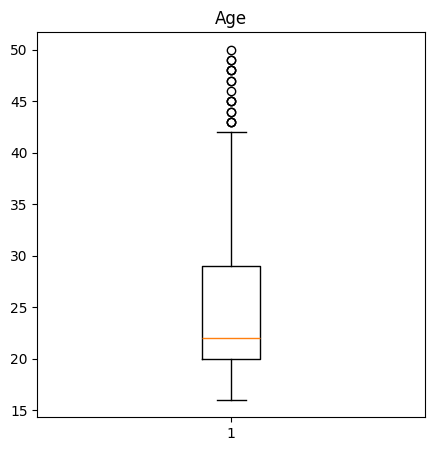

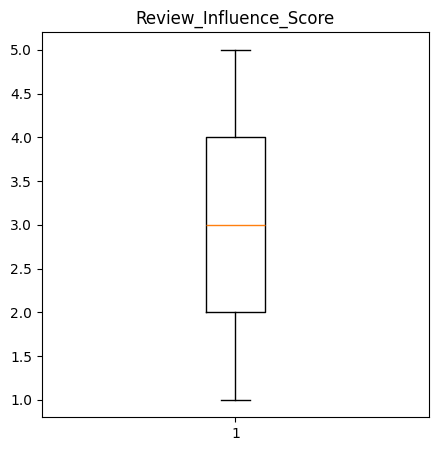

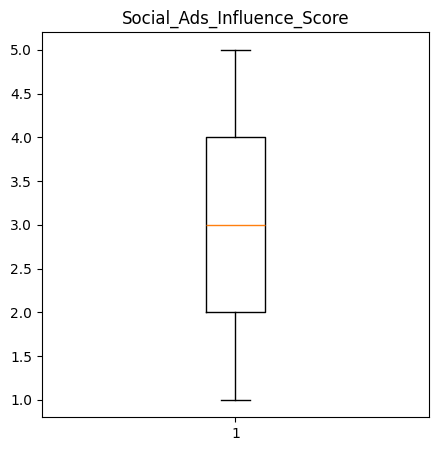

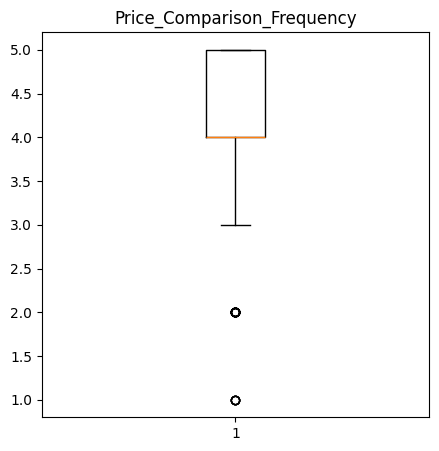

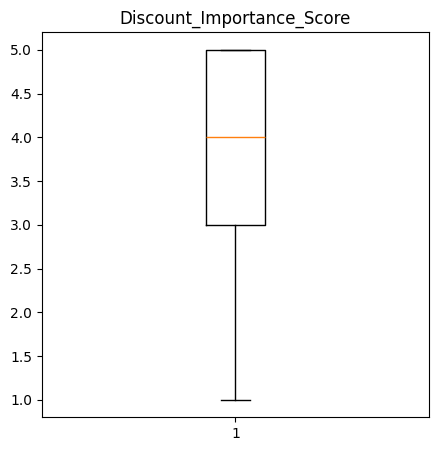

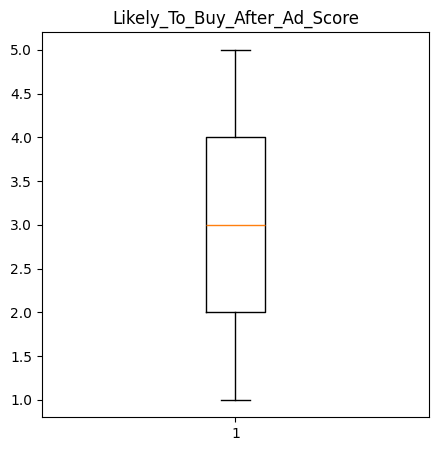

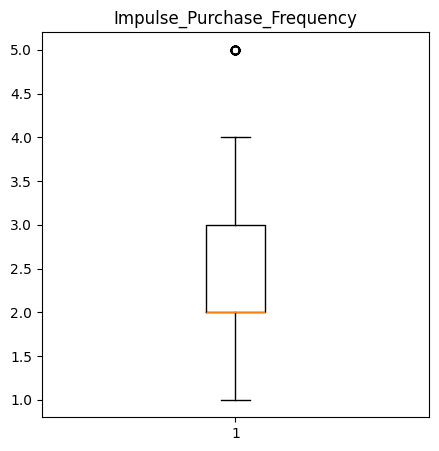

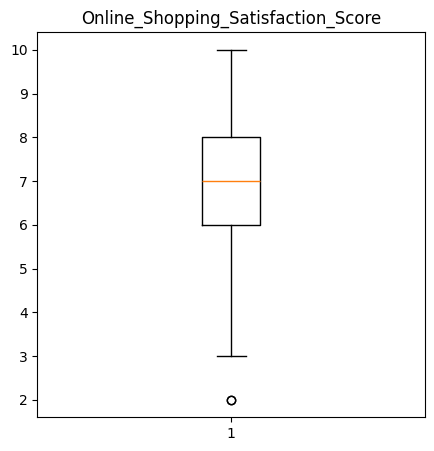

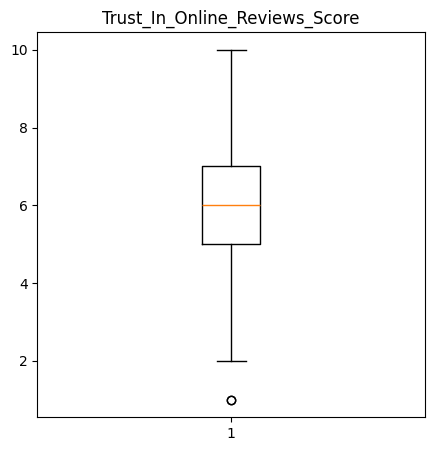

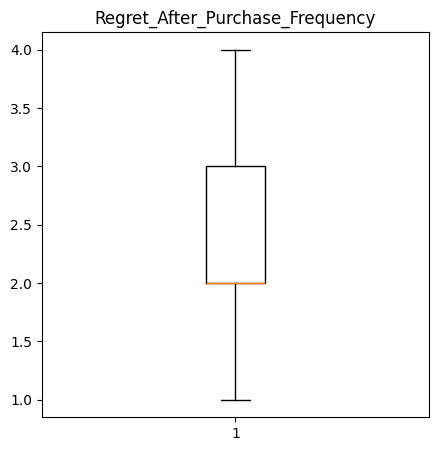

In [218]:
for i in num_cols :
  plt.figure(figsize = (5,5))
  plt.boxplot(df[i])
  plt.title(i)   #boxplots for identifying outliers

In [219]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder


In [220]:
#Label Encoding for ordinal feature
label_enc = LabelEncoder()
df['Online_Shopping_Frequency'] = label_enc.fit_transform(df['Online_Shopping_Frequency'].astype(str))



In [221]:
label_enc = LabelEncoder()
df['Return_Frequency'] = label_enc.fit_transform(df['Return_Frequency'].astype(str))

In [222]:
print(df.columns.tolist())

['Response_ID', 'Timestamp', 'Age', 'Gender', 'Occupation_Status', 'Country_Region', 'Monthly_Income_Range', 'Shop_Most_Where', 'Online_Shopping_Frequency', 'Preferred_Platform', 'Primary_Device', 'Top_Spending_Category', 'Review_Influence_Score', 'Social_Ads_Influence_Score', 'Price_Comparison_Frequency', 'Discount_Importance_Score', 'Follows_Brands_On_Social', 'Likely_To_Buy_After_Ad_Score', 'Makes_Shopping_List', 'Impulse_Purchase_Frequency', 'Return_Frequency', 'Avg_Monthly_Spend_NonEssentials', 'Preferred_Payment_Method', 'Uses_BNPL_Installments', 'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency', 'Reason_Prefer_Online', 'Reason_Prefer_InStore', 'Best_Shopping_Mode']


In [223]:
#One-Hot Encoding for nominal feature
df = pd.get_dummies(df, columns=['Preferred_Payment_Method', 'Country_Region','Gender','Occupation_Status','Monthly_Income_Range',
    'Shop_Most_Where','Preferred_Platform','Primary_Device','Top_Spending_Category',
    'Follows_Brands_On_Social','Makes_Shopping_List','Avg_Monthly_Spend_NonEssentials',
    'Uses_BNPL_Installments',
    'Reason_Prefer_Online','Reason_Prefer_InStore'], drop_first=True)



In [224]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [225]:
# Convert Timestamp to datetime and extract features
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['Hour'] = df['Timestamp'].dt.hour


In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 76 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   Response_ID                                          500 non-null    int64         
 1   Timestamp                                            164 non-null    datetime64[ns]
 2   Age                                                  500 non-null    float64       
 3   Online_Shopping_Frequency                            500 non-null    int64         
 4   Review_Influence_Score                               500 non-null    float64       
 5   Social_Ads_Influence_Score                           500 non-null    float64       
 6   Price_Comparison_Frequency                           500 non-null    float64       
 7   Discount_Importance_Score                            500 non-null    float64       
 8   

In [227]:
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

# Convert True/False to 1/0
df[bool_cols] = df[bool_cols].astype(int)

In [228]:
target = 'Best_Shopping_Mode'

# Split features and target
X = df.drop(columns=[target])
y = df[target]

# Perform train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)



Training set size: (400, 75)
Test set size: (100, 75)


In [229]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)


In [230]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['Gender','Occupation_Status','Country_Region', ...]  # your list
numerical_features = ['Age','Review_Influence_Score', ...]  # your list

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ])


In [232]:
from sklearn.preprocessing import StandardScaler

# Example: define actual numeric columns
numerical_features = [
    'Age','Review_Influence_Score','Social_Ads_Influence_Score',
    'Price_Comparison_Frequency','Discount_Importance_Score',
    'Likely_To_Buy_After_Ad_Score','Impulse_Purchase_Frequency',
    'Return_Frequency','Online_Shopping_Satisfaction_Score',
    'Trust_In_Online_Reviews_Score','Regret_After_Purchase_Frequency'
]

# Select only numeric columns
X_train_num = X_train[numerical_features]

# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test[numerical_features])


In [233]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE on the scaled training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_resampled.value_counts())


Before SMOTE:
 Best_Shopping_Mode
Online          215
Offline          94
Equal / both     91
Name: count, dtype: int64
After SMOTE:
 Best_Shopping_Mode
Equal / both    215
Online          215
Offline         215
Name: count, dtype: int64




1.   Encoding, Scaling and SMOTE . Data is imbalanced , so used SMOTE to balance data
2.   Yes, it is affected , Median is used in numerical columns and mode is used in categorical columns



Task 3

In [234]:
print(df.groupby('Best_Shopping_Mode')['Age'].describe())

                    count       mean       std   min   25%   50%   75%   max
Best_Shopping_Mode                                                          
Equal / both        113.0  23.389381  6.707450  16.0  20.0  21.0  24.0  48.0
Offline             118.0  25.618644  7.121557  16.0  20.0  23.5  31.0  48.0
Online              269.0  25.104089  7.591503  16.0  20.0  22.0  29.0  50.0


/tmp/ipykernel_2872/2547525787.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Best_Shopping_Mode', y='Age', data=df, palette='Set2')


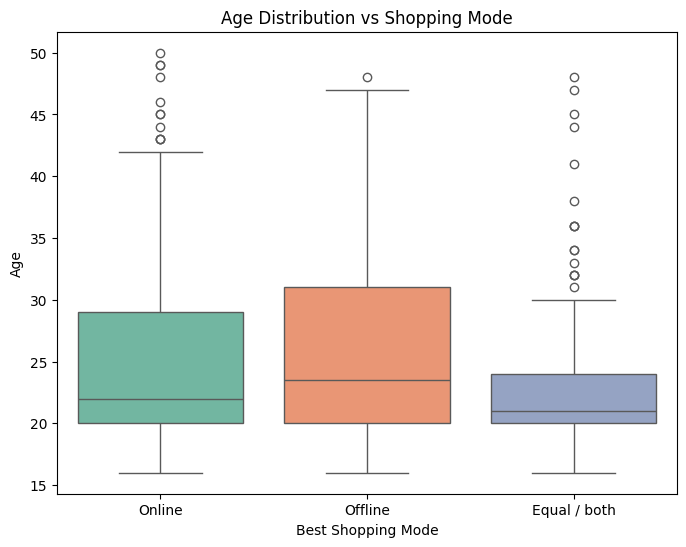

In [235]:
import seaborn as sns
import matplotlib.pyplot as plt
#Age vs Shopping Mode
plt.figure(figsize=(8,6))
sns.boxplot(x='Best_Shopping_Mode', y='Age', data=df, palette='Set2')
plt.title("Age Distribution vs Shopping Mode")
plt.xlabel("Best Shopping Mode")
plt.ylabel("Age")
plt.show()


In [238]:
print(df.columns.tolist())


['Response_ID', 'Timestamp', 'Age', 'Online_Shopping_Frequency', 'Review_Influence_Score', 'Social_Ads_Influence_Score', 'Price_Comparison_Frequency', 'Discount_Importance_Score', 'Likely_To_Buy_After_Ad_Score', 'Impulse_Purchase_Frequency', 'Return_Frequency', 'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency', 'Best_Shopping_Mode', 'Preferred_Payment_Method_Credit Card', 'Preferred_Payment_Method_Debit Card', 'Preferred_Payment_Method_Digital wallet', 'Country_Region_Colombia', 'Country_Region_Egypt', 'Country_Region_Germany', 'Country_Region_India', 'Country_Region_Indonesia', 'Country_Region_Kenya', 'Country_Region_Mexico', 'Country_Region_Nigeria', 'Country_Region_Pakistan', 'Country_Region_Philippines', 'Country_Region_Poland', 'Country_Region_Slovakia', 'Country_Region_South Africa', 'Country_Region_Turkiye', 'Country_Region_United Kingdom', 'Country_Region_United States', 'Country_Region_Vietnam', 'Gender_Male', 'Gender_Pref

In [239]:
df.columns = df.columns.str.strip()


In [259]:
print(df.columns.tolist())


['Response_ID', 'Timestamp', 'Age', 'Online_Shopping_Frequency', 'Review_Influence_Score', 'Social_Ads_Influence_Score', 'Price_Comparison_Frequency', 'Discount_Importance_Score', 'Likely_To_Buy_After_Ad_Score', 'Impulse_Purchase_Frequency', 'Return_Frequency', 'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency', 'Best_Shopping_Mode', 'Preferred_Payment_Method_Credit Card', 'Preferred_Payment_Method_Debit Card', 'Preferred_Payment_Method_Digital wallet', 'Country_Region_Colombia', 'Country_Region_Egypt', 'Country_Region_Germany', 'Country_Region_India', 'Country_Region_Indonesia', 'Country_Region_Kenya', 'Country_Region_Mexico', 'Country_Region_Nigeria', 'Country_Region_Pakistan', 'Country_Region_Philippines', 'Country_Region_Poland', 'Country_Region_Slovakia', 'Country_Region_South Africa', 'Country_Region_Turkiye', 'Country_Region_United Kingdom', 'Country_Region_United States', 'Country_Region_Vietnam', 'Gender_Male', 'Gender_Pref

Income vs Spending

/tmp/ipykernel_2872/2721647620.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Monthly_Income_Range_Under $1,000', y='Avg_Monthly_Spend_NonEssentials_$500+', data=df, palette='Set2')


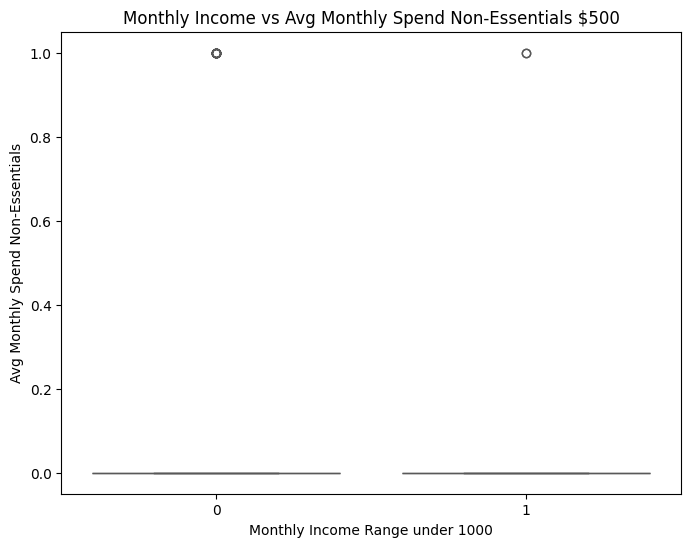

In [260]:
import seaborn as sns
import matplotlib.pyplot as plt
#Inome vs SPENDING
plt.figure(figsize=(8,6))
sns.boxplot(x='Monthly_Income_Range_Under $1,000', y='Avg_Monthly_Spend_NonEssentials_$500+', data=df, palette='Set2')
plt.title("Monthly Income vs Avg Monthly Spend Non-Essentials $500")
plt.xlabel("Monthly Income Range under 1000")
plt.ylabel("Avg Monthly Spend Non-Essentials")
plt.show()

Shopping Frequency

In [245]:
print(df['Online_Shopping_Frequency'].value_counts())
print(df['Online_Shopping_Frequency'].describe())


Online_Shopping_Frequency
1    259
2    132
3     58
0     51
Name: count, dtype: int64
count    500.000000
mean       1.394000
std        0.822263
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        3.000000
Name: Online_Shopping_Frequency, dtype: float64


/tmp/ipykernel_2872/3453290178.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Online_Shopping_Frequency', data=df, palette='Set2')


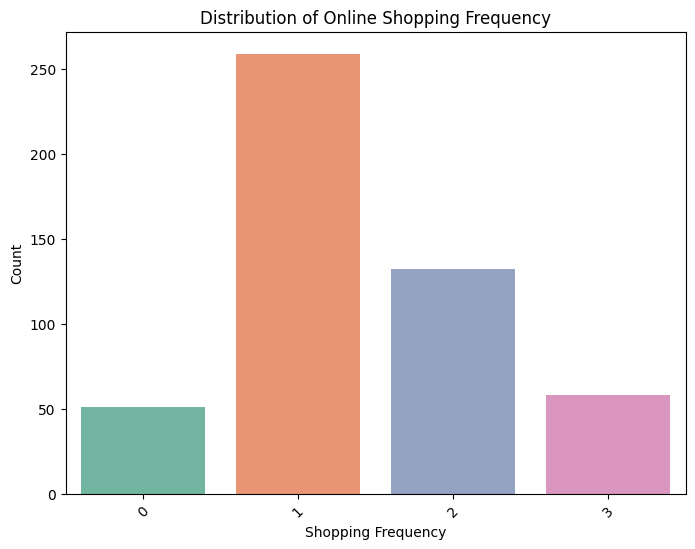

In [246]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.countplot(x='Online_Shopping_Frequency', data=df, palette='Set2')
plt.title("Distribution of Online Shopping Frequency")
plt.xlabel("Shopping Frequency")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_2872/3733522254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Online_Shopping_Frequency', y='Age', data=df, palette='Set3')


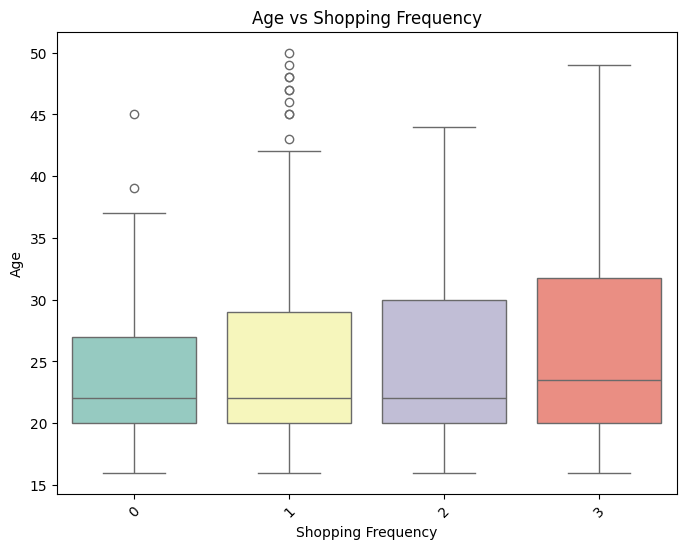

In [247]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Online_Shopping_Frequency', y='Age', data=df, palette='Set3')
plt.title("Age vs Shopping Frequency")
plt.xlabel("Shopping Frequency")
plt.ylabel("Age")
plt.xticks(rotation=45)
plt.show()


Satisfaction and Review Influence

In [248]:
print(df[['Online_Shopping_Satisfaction_Score','Review_Influence_Score']].corr())

print(df.groupby(pd.qcut(df['Review_Influence_Score'], 4))['Online_Shopping_Satisfaction_Score'].mean())


                                    Online_Shopping_Satisfaction_Score  \
Online_Shopping_Satisfaction_Score                            1.000000   
Review_Influence_Score                                        0.008267   

                                    Review_Influence_Score  
Online_Shopping_Satisfaction_Score                0.008267  
Review_Influence_Score                            1.000000  
Review_Influence_Score
(0.999, 2.0]    7.101266
(2.0, 3.0]      7.137725
(3.0, 4.0]      7.146341
(4.0, 5.0]      7.019231
Name: Online_Shopping_Satisfaction_Score, dtype: float64


/tmp/ipykernel_2872/2389579723.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.qcut(df['Review_Influence_Score'], 4))['Online_Shopping_Satisfaction_Score'].mean())


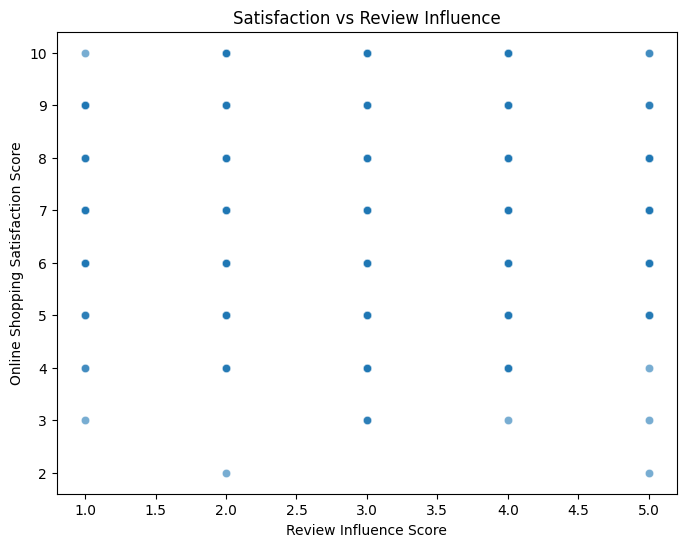

In [249]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(x='Review_Influence_Score', y='Online_Shopping_Satisfaction_Score', data=df, alpha=0.6)
plt.title("Satisfaction vs Review Influence")
plt.xlabel("Review Influence Score")
plt.ylabel("Online Shopping Satisfaction Score")
plt.show()


/tmp/ipykernel_2872/3861215466.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Review_Quartile', y='Online_Shopping_Satisfaction_Score', data=df, palette='Set2')


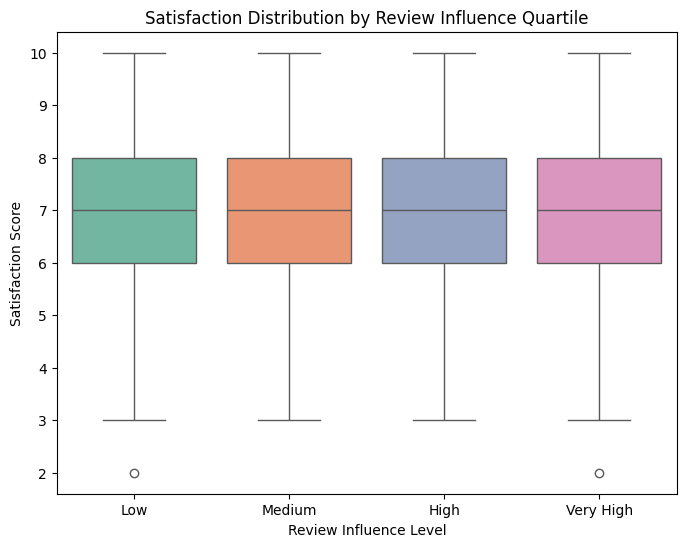

In [250]:
df['Review_Quartile'] = pd.qcut(df['Review_Influence_Score'], 4, labels=['Low','Medium','High','Very High'])

plt.figure(figsize=(8,6))
sns.boxplot(x='Review_Quartile', y='Online_Shopping_Satisfaction_Score', data=df, palette='Set2')
plt.title("Satisfaction Distribution by Review Influence Quartile")
plt.xlabel("Review Influence Level")
plt.ylabel("Satisfaction Score")
plt.show()


Payment Method distribution

In [253]:
print(df.columns.tolist())


['Response_ID', 'Timestamp', 'Age', 'Online_Shopping_Frequency', 'Review_Influence_Score', 'Social_Ads_Influence_Score', 'Price_Comparison_Frequency', 'Discount_Importance_Score', 'Likely_To_Buy_After_Ad_Score', 'Impulse_Purchase_Frequency', 'Return_Frequency', 'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency', 'Best_Shopping_Mode', 'Preferred_Payment_Method_Credit Card', 'Preferred_Payment_Method_Debit Card', 'Preferred_Payment_Method_Digital wallet', 'Country_Region_Colombia', 'Country_Region_Egypt', 'Country_Region_Germany', 'Country_Region_India', 'Country_Region_Indonesia', 'Country_Region_Kenya', 'Country_Region_Mexico', 'Country_Region_Nigeria', 'Country_Region_Pakistan', 'Country_Region_Philippines', 'Country_Region_Poland', 'Country_Region_Slovakia', 'Country_Region_South Africa', 'Country_Region_Turkiye', 'Country_Region_United Kingdom', 'Country_Region_United States', 'Country_Region_Vietnam', 'Gender_Male', 'Gender_Pref

In [254]:
print(df['Preferred_Payment_Method_Credit Card'].value_counts())
print(df['Preferred_Payment_Method_Credit Card'].value_counts(normalize=True) * 100)


Preferred_Payment_Method_Credit Card
0    391
1    109
Name: count, dtype: int64
Preferred_Payment_Method_Credit Card
0    78.2
1    21.8
Name: proportion, dtype: float64


/tmp/ipykernel_2872/1755692490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Preferred_Payment_Method_Credit Card', data=df, palette='Set2')


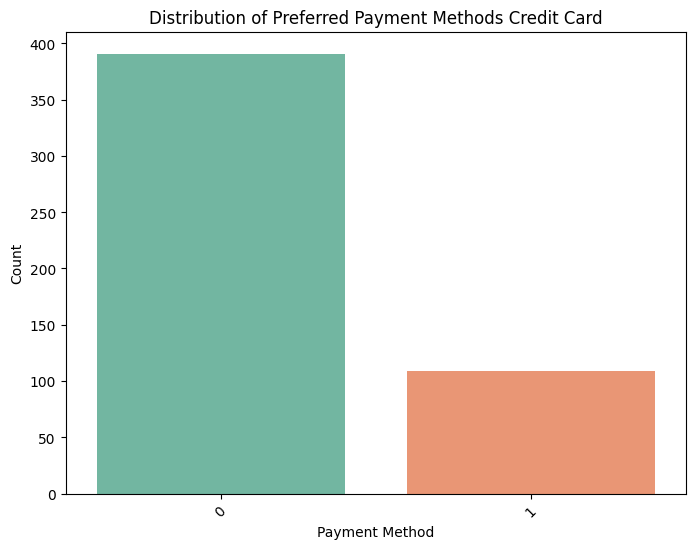

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.countplot(x='Preferred_Payment_Method_Credit Card', data=df, palette='Set2')
plt.title("Distribution of Preferred Payment Methods Credit Card")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [256]:
print(df['Preferred_Payment_Method_Debit Card'].value_counts())
print(df['Preferred_Payment_Method_Debit Card'].value_counts(normalize=True) * 100)


Preferred_Payment_Method_Debit Card
0    371
1    129
Name: count, dtype: int64
Preferred_Payment_Method_Debit Card
0    74.2
1    25.8
Name: proportion, dtype: float64


/tmp/ipykernel_2872/2582406696.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Preferred_Payment_Method_Debit Card', data=df, palette='Set2')


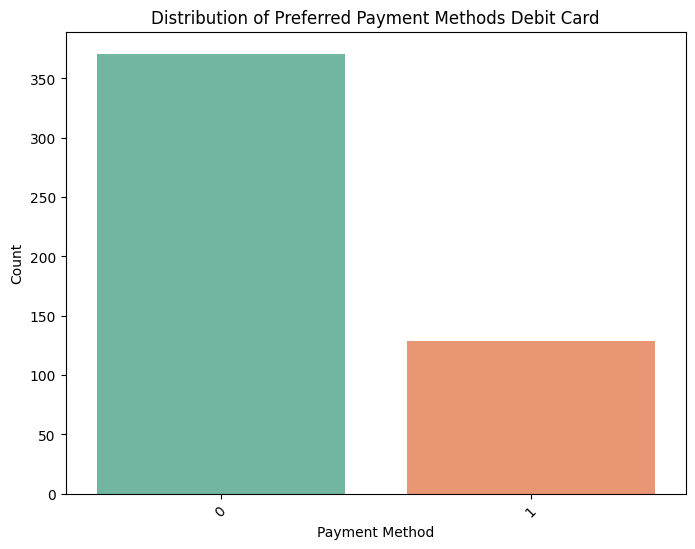

In [257]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.countplot(x='Preferred_Payment_Method_Debit Card', data=df, palette='Set2')
plt.title("Distribution of Preferred Payment Methods Debit Card")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

1,  Trust, convienient and place

2,  Yes

**Task 4**

Models - Classification Models

In [261]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [264]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [265]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='macro'))
print("Recall:", recall_score(y_test, y_pred_log, average='macro'))
print("F1:", f1_score(y_test, y_pred_log, average='macro'))


Logistic Regression
Accuracy: 0.49
Precision: 0.24269662921348312
Recall: 0.32042648709315374
F1: 0.26078088578088576


In [266]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [270]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

In [271]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='macro'))
print("Recall:", recall_score(y_test, y_pred_rf, average='macro'))
print("F1:", f1_score(y_test, y_pred_rf, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.45
Precision: 0.24887082204155375
Recall: 0.29447250280583614
F1: 0.2524917102715964

Classification Report:
               precision    recall  f1-score   support

Equal / both       0.11      0.05      0.06        22
     Offline       0.11      0.04      0.06        24
      Online       0.52      0.80      0.63        54

    accuracy                           0.45       100
   macro avg       0.25      0.29      0.25       100
weighted avg       0.33      0.45      0.37       100



In [274]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

In [275]:
print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb, average='macro'))
print("Recall:", recall_score(y_test, y_pred_gb, average='macro'))
print("F1:", f1_score(y_test, y_pred_gb, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Results
Accuracy: 0.4
Precision: 0.31432411674347155
Recall: 0.3047138047138047
F1: 0.30330887187984956

Classification Report:
               precision    recall  f1-score   support

Equal / both       0.12      0.14      0.13        22
     Offline       0.29      0.17      0.21        24
      Online       0.53      0.61      0.57        54

    accuracy                           0.40       100
   macro avg       0.31      0.30      0.30       100
weighted avg       0.38      0.40      0.39       100



In [276]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

In [277]:
print("Support Vector Machine Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='macro'))
print("Recall:", recall_score(y_test, y_pred_svm, average='macro'))
print("F1:", f1_score(y_test, y_pred_svm, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

Support Vector Machine Results
Accuracy: 0.53
Precision: 0.17845117845117844
Recall: 0.3271604938271605
F1: 0.23093681917211328

Classification Report:
               precision    recall  f1-score   support

Equal / both       0.00      0.00      0.00        22
     Offline       0.00      0.00      0.00        24
      Online       0.54      0.98      0.69        54

    accuracy                           0.53       100
   macro avg       0.18      0.33      0.23       100
weighted avg       0.29      0.53      0.37       100



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

In [279]:

results = {}
# Logistic Regression
results['Logistic Regression'] = {
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log, average='macro'),
    "Recall": recall_score(y_test, y_pred_log, average='macro'),
    "F1": f1_score(y_test, y_pred_log, average='macro')
}

# Random Forest
results['Random Forest'] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, average='macro'),
    "Recall": recall_score(y_test, y_pred_rf, average='macro'),
    "F1": f1_score(y_test, y_pred_rf, average='macro')
}

# Gradient Boosting
results['Gradient Boosting'] = {
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb, average='macro'),
    "Recall": recall_score(y_test, y_pred_gb, average='macro'),
    "F1": f1_score(y_test, y_pred_gb, average='macro')
}

# SVM
results['SVM'] = {
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm, average='macro'),
    "Recall": recall_score(y_test, y_pred_svm, average='macro'),
    "F1": f1_score(y_test, y_pred_svm, average='macro')
}

# Convert to DataFrame for easy comparison
df_results = pd.DataFrame(results).T
print(df_results)


                     Accuracy  Precision    Recall        F1
Logistic Regression      0.49   0.242697  0.320426  0.260781
Random Forest            0.45   0.248871  0.294473  0.252492
Gradient Boosting        0.40   0.314324  0.304714  0.303309
SVM                      0.53   0.178451  0.327160  0.230937


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


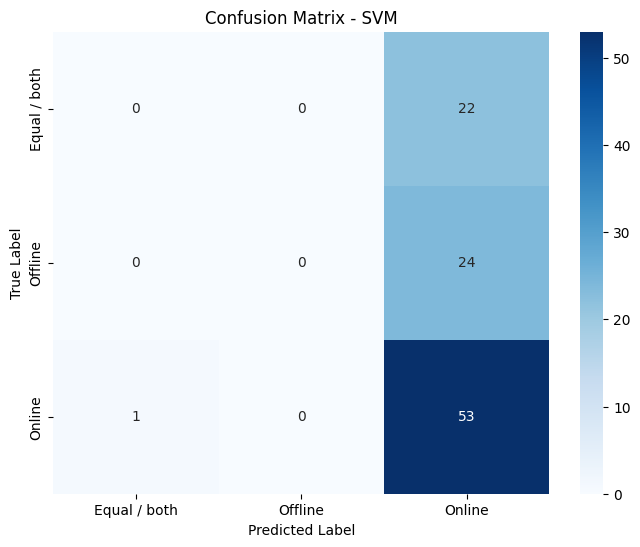

In [280]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
#Most important features for predictions ,
Discount_Importance_Score

Online_Shopping_Satisfaction_Score

Trust_In_Online_Reviews_Score

Preferred_Payment_Method

Monthly_Income_Range

1,SVM model is performed well , because SVM don’t provide feature importance directly


2, Discount_Importance_Score , Online_Shopping_Satisfaction_Score, Trust_In_Online_Reviews_Score , Preferred_Payment_Method , Monthly_Income_Range

3,Larger absolute values indicate stronger influence on the decision boundary.





In [283]:
import pandas as pd

# 1. Create comparison DataFrame for the first 100 test samples
comparison_df = pd.DataFrame({
    'Actual': y_test.values[:100],
    'Predicted': y_pred_svm[:100]
}).reset_index(drop=True)

# 2. Add a column to flag mismatches
comparison_df['Match?'] = comparison_df['Actual'] == comparison_df['Predicted']

# 3. Display the top 10 rows
print(comparison_df.head(10))


         Actual Predicted  Match?
0        Online    Online    True
1        Online    Online    True
2       Offline    Online   False
3        Online    Online    True
4       Offline    Online   False
5        Online    Online    True
6       Offline    Online   False
7        Online    Online    True
8  Equal / both    Online   False
9        Online    Online    True


Task 5

In [ ]:
1, Marketing ROI , Sales Growth , reduced returns
2,